In [1]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

Downloaded thinkstats.py


In [2]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empiricaldist: filename=empiricaldist-0.9.0-py3-none-any.whl size=14297 sha256=6ea6575f6b299ba4ab986fa6e5bc2a99b0a34f9ae66fbc442c6d83553c46bc1b
  Stored in directory: /root/.cache/pip/wheels/26/56/da/ea90b6b66dc5e72379a64e2819815066873f00c1350126e876
Successfully built empiricaldist


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

In [4]:
download(
    "https://gist.github.com/epogrebnyak/7933e16c0ad215742c4c104be4fbdeb1/raw/c932bc5b6aa6317770c4cbf43eb591511fec08f9/lamps.csv"
)

Downloaded lamps.csv


In [5]:
df = pd.read_csv("lamps.csv", index_col=0)
df.tail()

,h,f,K
i,,,
28,1812,1,4
29,1836,1,3
30,1860,1,2
31,1980,1,1
32,2568,1,0


In [6]:
from empiricaldist import Pmf

pmf_bulblife = Pmf(df["f"].values, index=df["h"])
pmf_bulblife.normalize()

np.int64(50)

In [7]:
cdf_bulblife = pmf_bulblife.make_cdf()
cdf_bulblife[1656]

np.float64(0.7800000000000002)

In [8]:
complementary_cdf = 1 - cdf_bulblife
complementary_cdf[1656]

np.float64(0.21999999999999975)

In [9]:
surv_bulblife = cdf_bulblife.make_surv()
surv_bulblife[1656]

np.float64(0.21999999999999997)

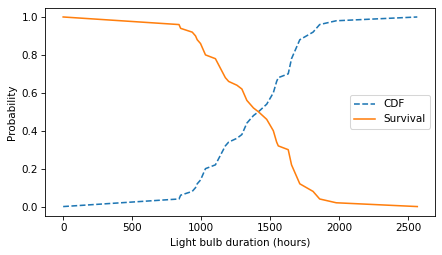

In [10]:
cdf_bulblife.plot(ls="--", label="CDF")
surv_bulblife.plot(label="Survival")

decorate(xlabel="Light bulb duration (hours)", ylabel="Probability")

In [11]:
at_risk = pmf_bulblife + surv_bulblife
at_risk[1656]

np.float64(0.25999999999999995)

In [12]:
pmf_bulblife[1656]

np.float64(0.04)

In [13]:
hazard = pmf_bulblife / at_risk
hazard[1656]

np.float64(0.15384615384615388)

In [14]:
hazard_bulblife = surv_bulblife.make_hazard()
hazard_bulblife[1656]

np.float64(0.15384615384615397)

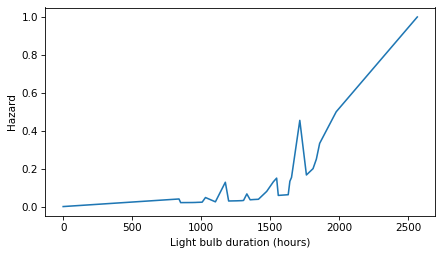

In [15]:
hazard_bulblife.plot()
decorate(xlabel="Light bulb duration (hours)", ylabel="Hazard")

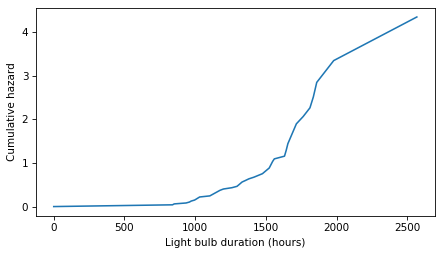

In [16]:
cumulative_hazard = hazard_bulblife.cumsum()
cumulative_hazard.plot()

decorate(xlabel="Light bulb duration (hours)", ylabel="Cumulative hazard")

In [17]:
filename = "marriage_nsfg_female.csv.gz"
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/" + filename)

Downloaded marriage_nsfg_female.csv.gz


In [18]:
resp = pd.read_csv("marriage_nsfg_female.csv.gz")
resp.shape

(70183, 34)

In [19]:
month0 = pd.to_datetime("1899-12-31")


def decade_of_birth(cmbirth):
    date = month0 + pd.DateOffset(months=cmbirth)
    return date.year // 10 * 10

In [20]:
from thinkstats import value_counts

resp["cohort"] = resp["cmbirth"].apply(decade_of_birth)
value_counts(resp["cohort"])

,count
cohort,
1930,325
1940,3608
1950,10631
1960,14953
1970,16438
1980,14271
1990,8552
2000,1405


In [21]:
resp["agemarr"] = (resp["cmmarrhx"] - resp["cmbirth"]) / 12
resp["age"] = (resp["cmintvw"] - resp["cmbirth"]) / 12

In [22]:
from empiricaldist import Surv


def make_survival_map(resp, cohorts):
    surv_map = {}

    grouped = resp.groupby("cohort")
    for cohort in cohorts:
        group = grouped.get_group(cohort)
        surv_map[cohort] = Surv.from_seq(group["agemarr"], dropna=False)

    return surv_map

In [23]:
cohorts = [1980, 1960, 1940]
surv_map = make_survival_map(resp, cohorts)

In [24]:
import matplotlib.pyplot as plt
import cycler

# Extract the default color cycle
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Define the desired line styles
linestyles = ["--", "-", "-.", "--", "-", "-.", "--", "-", "-.", "--"]

# Ensure we cycle through styles and colors properly
custom_cycler = cycler.cycler(color=default_colors) + cycler.cycler(
    linestyle=linestyles
)

# Apply the new cycler
plt.rc("axes", prop_cycle=custom_cycler)

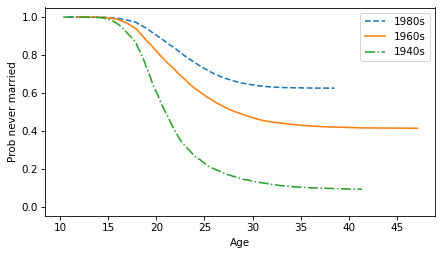

In [25]:
for cohort, surv in surv_map.items():
    surv.plot(label=f"{cohort}s")

ylim = [-0.05, 1.05]
decorate(xlabel="Age", ylabel="Prob never married", ylim=ylim)

In [26]:
def resample_rows_weighted(df, column="finalwgt"):
    n = len(df)
    weights = df[column]
    return df.sample(n, weights=weights, replace=True)

In [27]:
def resample_cycles(resp):
    grouped = resp.groupby("cycle")
    samples = [resample_rows_weighted(group) for _, group in grouped]
    return pd.concat(samples)

In [28]:
# Seed the random number generator so we get the same results every time
np.random.seed(1)

In [29]:
sample = resample_cycles(resp)

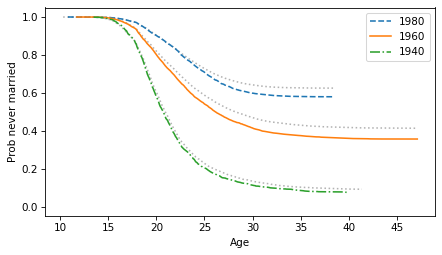

In [30]:
for label, surv in surv_map.items():
    surv.plot(ls=":", color="gray", alpha=0.6)

survs_resampled = make_survival_map(sample, cohorts)

for label, surv in survs_resampled.items():
    surv.plot(label=label)

decorate(xlabel="Age", ylabel="Prob never married", ylim=ylim)

In [31]:
plt.rc("axes", prop_cycle=plt.rcParamsDefault["axes.prop_cycle"])

In [32]:
resp60 = sample.query("cohort == 1960")

In [33]:
complete = resp60.query("evrmarry == 1")["agemarr"]
complete.count()

np.int64(9921)

In [34]:
ongoing = resp60.query("evrmarry == 0")["age"]
ongoing.count()

np.int64(5468)

In [35]:
from empiricaldist import FreqTab

ft_complete = FreqTab.from_seq(complete)
ft_ongoing = FreqTab.from_seq(ongoing)

In [36]:
ft_complete[25]

np.int64(58)

In [37]:
ft_ongoing[25]

np.int64(5)

In [38]:
surv_complete = ft_complete.make_surv()
surv_ongoing = ft_ongoing.make_surv()

In [39]:
surv_complete[25]

np.int64(2848)

In [40]:
surv_ongoing[25]

np.int64(2273)

In [41]:
at_risk = ft_complete[25] + ft_ongoing[25] + surv_complete[25] + surv_ongoing[25]
at_risk

np.int64(5184)

In [42]:
hazard = ft_complete[25] / at_risk
hazard

np.float64(0.011188271604938271)

In [43]:
ts = pd.Index.union(ft_complete.index, ft_ongoing.index)

In [44]:
at_risk = ft_complete(ts) + ft_ongoing(ts) + surv_complete(ts) + surv_ongoing(ts)

In [45]:
from empiricaldist import Hazard

hs = ft_complete(ts) / at_risk
hazard = Hazard(hs, ts)

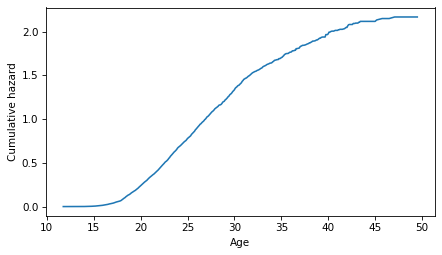

In [46]:
hazard.cumsum().plot()

decorate(xlabel="Age", ylabel="Cumulative hazard")

In [47]:
ps = (1 - hazard).cumprod()

In [48]:
surv = hazard.make_surv()

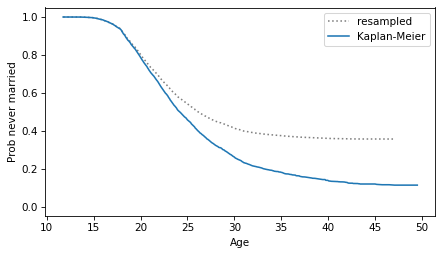

In [49]:
survs_resampled[1960].plot(ls=":", color="gray", label="resampled")
surv.plot(label="Kaplan-Meier")

decorate(xlabel="Age", ylabel="Prob never married", ylim=ylim)

In [50]:
def estimate_hazard(complete, ongoing):
    """Kaplan-Meier estimation."""
    ft_complete = FreqTab.from_seq(complete)
    ft_ongoing = FreqTab.from_seq(ongoing)

    surv_complete = ft_complete.make_surv()
    surv_ongoing = ft_ongoing.make_surv()

    ts = pd.Index.union(ft_complete.index, ft_ongoing.index)
    at_risk = ft_complete(ts) + ft_ongoing(ts) + surv_complete(ts) + surv_ongoing(ts)

    hs = ft_complete(ts) / at_risk
    return Hazard(hs, ts)

In [51]:
def estimate_survival(group):
    """Estimate the survival function."""
    complete = group.query("evrmarry == 1")["agemarr"]
    ongoing = group.query("evrmarry == 0")["age"]
    hf = estimate_hazard(complete, ongoing)
    sf = hf.make_surv()
    return sf

In [52]:
try:
    import lifelines
except ImportError:
    %pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=f3da9c5f1dbbd7848ff86d4a2d37a9999aa254cd0b72760399a8af204edc98cf
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [53]:
surv = estimate_survival(resp60)

In [54]:
complete = complete.dropna()
durations = np.concatenate([complete, ongoing])
event_observed = np.concatenate([np.ones(len(complete)), np.zeros(len(ongoing))])

In [55]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(durations=durations, event_observed=event_observed)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 15389 total observations, 5468 right-censored observations>

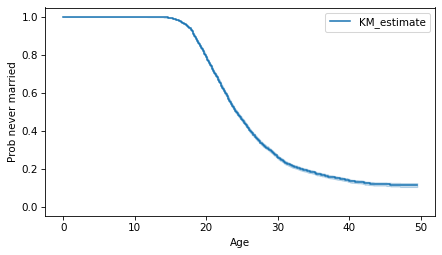

In [56]:
kmf.plot()

decorate(xlabel="Age", ylabel="Prob never married", ylim=ylim)

In [57]:
ps = kmf.survival_function_["KM_estimate"].drop(0)
np.allclose(ps, surv)

True

In [58]:
def estimate_survival_map(resp, cohorts):
    """Make a dictionary from cohorts to Surv objects."""
    surv_map = {}

    grouped = resp.groupby("cohort")
    for cohort in cohorts:
        group = grouped.get_group(cohort)
        surv_map[cohort] = estimate_survival(group)

    return surv_map

In [59]:
cohorts = [1940, 1950, 1960, 1970, 1980, 1990]

surv_maps = [estimate_survival_map(resample_cycles(resp), cohorts) for i in range(101)]

In [60]:
def plot_cohort(surv_maps, cohort, color):
    """Plot results for a single cohort."""
    survs = [surv_map[cohort] for surv_map in surv_maps]
    for surv in survs:
        surv.plot(color=color, alpha=0.05)

    x, y = surv.index[-1], surv.iloc[-1]
    plt.text(x + 1, y, f"{cohort}s", ha="left", va="center")

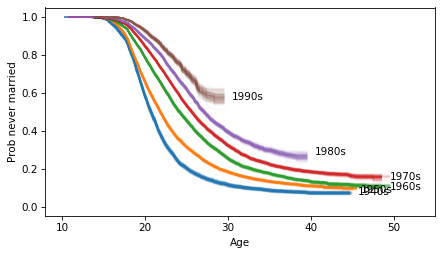

In [61]:
colors = [f"C{i}" for i in range(len(cohorts))]

for cohort, color in zip(cohorts, colors):
    plot_cohort(surv_maps, cohort, color)

xlim = [8, 55]
decorate(xlabel="Age", ylabel="Prob never married", xlim=xlim, ylim=ylim)

In [62]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")

Downloaded nsfg.py
Downloaded 2002FemPreg.dct
Downloaded 2002FemPreg.dat.gz


In [63]:
try:
    import statadict
except ImportError:
    %pip install statadict

In [64]:
from nsfg import get_nsfg_groups

live, firsts, others = get_nsfg_groups()

In [65]:
sample = resample_rows_weighted(live, "finalwgt")

In [66]:
pmf_durations = Pmf.from_seq(sample["prglngth"])

In [67]:
t = 36
is_remaining = pmf_durations.qs >= t

In [68]:
ps = pmf_durations.ps[is_remaining]
qs = pmf_durations.qs[is_remaining] - t

pmf_remaining = Pmf(ps, qs)

In [69]:
pmf_remaining.normalize()

np.float64(0.9155006558810669)

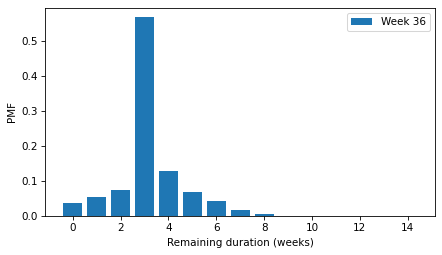

In [70]:
pmf_remaining.bar(label="Week 36")
decorate(xlabel="Remaining duration (weeks)", ylabel="PMF")

In [71]:
pmf_remaining.mean()

np.float64(3.2145671641791043)

In [72]:
def compute_pmf_remaining(pmf, t):
    """Distribution of remaining time."""
    is_remaining = pmf.qs >= t
    ps = pmf.ps[is_remaining]
    qs = pmf.qs[is_remaining] - t
    pmf_remaining = Pmf(ps, qs)
    pmf_remaining.normalize()
    return pmf_remaining

In [73]:
def expected_remaining(pmf):
    index = range(36, 44)
    expected = pd.Series(index=index)

    for t in index:
        pmf_remaining = compute_pmf_remaining(pmf, t)
        expected[t] = pmf_remaining.mean()

    return expected

In [74]:
expected = expected_remaining(pmf_durations)
expected

,0
36,3.214567
37,2.337714
38,1.479095
39,0.610133
40,0.912517
41,0.784211
42,0.582301
43,0.589372


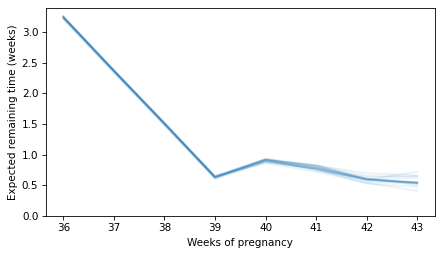

In [75]:
for i in range(21):
    sample = resample_rows_weighted(live, "finalwgt")
    pmf_durations = Pmf.from_seq(sample["prglngth"])
    expected = expected_remaining(pmf_durations)
    expected.plot(color="C0", alpha=0.1)

decorate(
    xlabel="Weeks of pregnancy", ylabel="Expected remaining time (weeks)", ylim=[0, 3.4]
)

In [88]:
# Exercise 13.1

!wget -q https://raw.githubusercontent.com/AllenDowney/ThinkStats/v3/nb/nsfg.py
!wget -q https://raw.githubusercontent.com/AllenDowney/ThinkStats/v3/code/statadict.py
!wget -q https://raw.githubusercontent.com/AllenDowney/ThinkStats/v3/code/thinkstats.py

sample = resample_cycles(resp)

In [89]:
import sys
sys.path.append(".")

In [90]:
import nsfg
import importlib
importlib.reload(nsfg)

<module 'nsfg' from '/content/nsfg.py'>

In [96]:
resp.columns
resp.shape

(70183, 37)

In [97]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [99]:
# Complete cases:
# marriages that ended in divorce

complete = resp[
    ['cmmarrhx', 'cmdivorcx']
].dropna()

# Marriage duration in months

complete['duration'] = (
    complete['cmdivorcx'] -
    complete['cmmarrhx']
)

# Remove impossible values

complete = complete[
    complete['duration'] >= -12
]

print(complete.head())

    cmmarrhx  cmdivorcx  duration
4     1338.0     1398.0      60.0
30    1254.0     1266.0      12.0
37    1182.0     1182.0       0.0
45    1242.0     1374.0     132.0
51    1278.0     1314.0      36.0


In [100]:
# Ongoing marriages:
# married once and still married

ongoing = resp[
    (resp['fmarno'] == 1) &
    (resp['rmarital'] == 1)
]

In [101]:
# Compute duration so far

# interview date column
# cmintvw = century month interview date

ongoing = ongoing[
    ['cmmarrhx', 'cmintvw']
].dropna()

ongoing['duration'] = (
    ongoing['cmintvw'] -
    ongoing['cmmarrhx']
)

ongoing = ongoing[
    ongoing['duration'] >= -12
]

print(ongoing.head())

    cmmarrhx  cmintvw  duration
3     1326.0     1433     107.0
7     1386.0     1435      49.0
11    1194.0     1426     232.0
14    1110.0     1433     323.0
15    1326.0     1426     100.0


In [102]:
# Create event indicators

complete['event'] = 1
ongoing['event'] = 0

In [103]:
# Combine datasets

survival_df = pd.concat([
    complete[['duration', 'event']],
    ongoing[['duration', 'event']]
])

print(survival_df.head())

    duration  event
4       60.0      1
30      12.0      1
37       0.0      1
45     132.0      1
51      36.0      1


In [104]:
# Install lifelines if needed

!pip install lifelines -q

In [105]:
# Kaplan-Meier survival estimate

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_df['duration'],
    event_observed=survival_df['event']
)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 32148 total observations, 22745 right-censored observations>

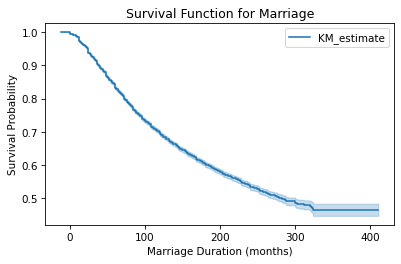

In [106]:
# Plot survival function

kmf.plot_survival_function()

plt.xlabel("Marriage Duration (months)")
plt.ylabel("Survival Probability")
plt.title("Survival Function for Marriage")

plt.show()

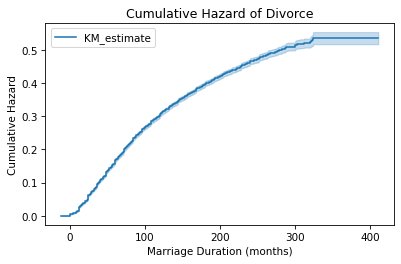

In [107]:
# Plot cumulative hazard

kmf.plot_cumulative_density()

plt.xlabel("Marriage Duration (months)")
plt.ylabel("Cumulative Hazard")
plt.title("Cumulative Hazard of Divorce")

plt.show()

In [79]:
# Exercise 13.2

download(
    "https://github.com/AllenDowney/ThinkStats/raw/v3/data/mortality_rates_beltran2012.csv"
)

Downloaded mortality_rates_beltran2012.csv


In [80]:
mortality = pd.read_csv("mortality_rates_beltran2012.csv", header=[0, 1]).dropna()

In [81]:
from scipy.interpolate import interp1d
from empiricaldist import Hazard


def make_hazard(ages, rates):
    """Make a Hazard function by interpolating a Series.

    series: Series

    returns: Hazard
    """
    interp = interp1d(ages, rates, fill_value="extrapolate")
    xs = np.arange(0, 100)
    ys = np.exp(interp(xs))
    return Hazard(ys, xs)

In [82]:
ages = mortality["1800", "X"].values
rates = mortality["1800", "Y"].values
hazard = make_hazard(ages, rates)

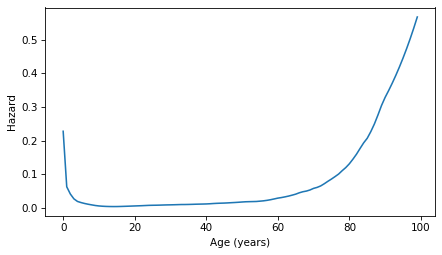

In [83]:
hazard.plot()

decorate(xlabel="Age (years)", ylabel="Hazard")

In [84]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [85]:
# Download mortality data

!wget -nc https://raw.githubusercontent.com/AllenDowney/ThinkStats/v3/data/mortality_rates.csv

--2026-05-17 16:05:25--  https://raw.githubusercontent.com/AllenDowney/ThinkStats/v3/data/mortality_rates.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-17 16:05:26 ERROR 404: Not Found.



In [109]:
import pandas as pd

mortality = pd.read_csv("mortality_rates_beltran2012.csv")

print(mortality.head())

                  1905               1905.1                 1800  \
0                    X                    Y                    X   
1  0.05663269422110062  -2.6857440215944948  0.06651518003603485   
2   0.1752225240003238  -2.8662129795080413  0.22463495307500025   
3  0.29381235377954873   -3.043188989849067  0.36298975448409543   
4   0.4124021835587719  -3.2166720526175725   0.4815795842633186   

                1800.1  
0                    Y  
1  -1.5412215336653614  
2  -1.6925825951412392  
3   -1.890516290917386  
4  -2.0529383530395773  


In [111]:
import os
os.listdir()

['.config',
 'mortality_rates_beltran2012.csv',
 '2002FemPreg.dat.gz',
 'marriage_nsfg_female.csv.gz',
 'nsfg.py.1',
 '2002FemPreg.dct',
 'nsfg.py',
 'lamps.csv',
 '__pycache__',
 'thinkstats.py',
 'sample_data']

In [114]:
# Read data

mortality = pd.read_csv("mortality_rates_beltran2012.csv", encoding="latin1")

print(mortality.head())

                  1905               1905.1                 1800  \
0                    X                    Y                    X   
1  0.05663269422110062  -2.6857440215944948  0.06651518003603485   
2   0.1752225240003238  -2.8662129795080413  0.22463495307500025   
3  0.29381235377954873   -3.043188989849067  0.36298975448409543   
4   0.4124021835587719  -3.2166720526175725   0.4815795842633186   

                1800.1  
0                    Y  
1  -1.5412215336653614  
2  -1.6925825951412392  
3   -1.890516290917386  
4  -2.0529383530395773  


In [124]:
mortality.columns

Index(['1905', '1905.1', '1800', '1800.1'], dtype='object')

In [125]:
import pandas as pd

mortality = pd.read_csv(
    "mortality_rates_beltran2012.csv",
    header=None
)

mortality.head()

,0,1,2,3
0,1905,1905,1800,1800
1,X,Y,X,Y
2,0.05663269422110062,-2.6857440215944948,0.06651518003603485,-1.5412215336653614
3,0.1752225240003238,-2.8662129795080413,0.22463495307500025,-1.6925825951412392
4,0.29381235377954873,-3.043188989849067,0.36298975448409543,-1.890516290917386


In [129]:
mortality.head()

mortality.shape

(162, 4)

In [130]:
mortality.columns = ["age", "hazard_1", "hazard_2", "hazard_3"]

In [131]:
# Extract age and hazard rate

age = mortality['age']

hazard = mortality['hazard_1']

In [117]:
# Compute survival function

survival = [1]

for h in hazard:

    survival.append(
        survival[-1] * (1 - h)
    )

survival = survival[:-1]

survival = np.array(survival)

In [133]:
import matplotlib.pyplot as plt
import numpy as np

In [135]:
import pandas as pd
import matplotlib.pyplot as plt

# convert to numeric (VERY IMPORTANT)
hazard = pd.to_numeric(mortality["hazard_1"], errors="coerce")
age = pd.to_numeric(mortality["age"], errors="coerce")

# compute survival
survival = (1 - hazard).cumprod()

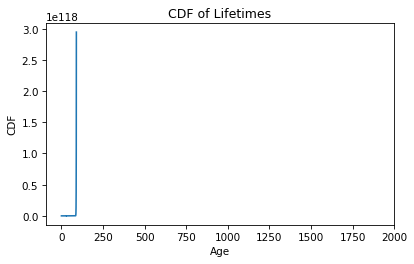

In [136]:
# Compute CDF

cdf = 1 - survival

plt.plot(age, cdf)

plt.xlabel("Age")
plt.ylabel("CDF")
plt.title("CDF of Lifetimes")

plt.show()

In [120]:
# Compute PMF of deaths

pmf = []

for i in range(len(hazard)):

    p = survival[i] * hazard.iloc[i]

    pmf.append(p)

pmf = np.array(pmf)

In [138]:
import pandas as pd
import matplotlib.pyplot as plt

hazard = pd.to_numeric(mortality["hazard_1"], errors="coerce")
age = pd.to_numeric(mortality["age"], errors="coerce")

In [139]:
pmf = hazard * (1 - hazard).cumprod().shift(fill_value=1)

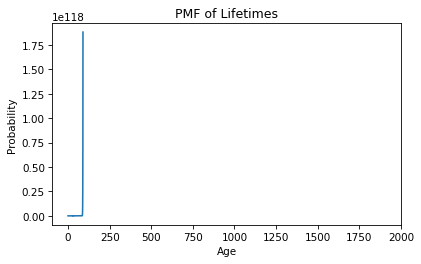

In [140]:
plt.plot(age, pmf)

plt.xlabel("Age")
plt.ylabel("Probability")
plt.title("PMF of Lifetimes")

plt.show()

In [141]:
# Compute remaining lifetime

remaining = []

for i in range(len(age)):

    probs = pmf[i:]

    ages_remaining = age.iloc[i:]

    expected = np.sum(
        probs * (ages_remaining - age.iloc[i])
    ) / probs.sum()

    remaining.append(expected)

remaining = np.array(remaining)

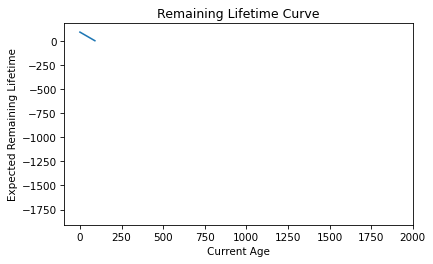

In [142]:
# Plot expected remaining lifetime

plt.plot(age, remaining)

plt.xlabel("Current Age")
plt.ylabel("Expected Remaining Lifetime")
plt.title("Remaining Lifetime Curve")

plt.show()